# Plotting notebook for reserve study outputs

This notebook loads the CSVs produced by the runner and recreates the plotting blocks without rerunning the full reserve-study pipeline.


In [2]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import calendar

PROJECT_ROOT = Path.cwd()
VARIANT_NAME = "2026_board_collab"

BASE_DIR = PROJECT_ROOT / VARIANT_NAME
SOURCE_DATA = BASE_DIR / "source_data"
WORKING_CSV = BASE_DIR / "working_csv"

ASSUMPTIONS_FILE = SOURCE_DATA / "assumptions.csv"
ASSESSMENT_FILE = SOURCE_DATA / "assessment_contributions.csv"
EXP_SUMMARY_FILE = WORKING_CSV / "expenditures_by_year_summary.csv"
RESERVE_PROJECTION_FILE = WORKING_CSV / "reserve_projection.csv"


In [3]:

# Load assumptions
assumptions_df = pd.read_csv(ASSUMPTIONS_FILE)
assumptions_map = dict(zip(assumptions_df["Parameter"], assumptions_df["Value"]))

analysis_date = pd.to_datetime(assumptions_map["Analysis Date"])
analysis_year = analysis_date.year
inflation = float(assumptions_map["Inflation"])

# Load runner outputs
assessment_contributions = pd.read_csv(ASSESSMENT_FILE).copy()
assessment_contributions["year"] = pd.to_numeric(
    assessment_contributions["year"], errors="coerce"
).astype(int)

assessment_contributions["contribution"] = pd.to_numeric(
    assessment_contributions["annual_contribution"], errors="coerce"
).fillna(0.0)

assessment_contributions["special_assessment"] = pd.to_numeric(
    assessment_contributions["special_assessment"], errors="coerce"
).fillna(0.0)

expenditures_by_year_summary = pd.read_csv(EXP_SUMMARY_FILE).copy()
reserve_projection = pd.read_csv(RESERVE_PROJECTION_FILE).copy()


In [4]:

def find_milestone_info(df, annual_col, fraction, timeline_start, timeline_end):
    target = df[annual_col].sum() * fraction

    running_before = 0.0
    crossing_x = None
    crossing_month_year = None

    for _, row in df.iterrows():
        yr = int(row["year"])
        annual_val = float(row[annual_col])
        running_after = running_before + annual_val

        if running_after >= target:
            frac_through_year = 0.0 if annual_val == 0 else (target - running_before) / annual_val
            crossing_x = yr + frac_through_year

            month_num = min(max(int(frac_through_year * 12) + 1, 1), 12)
            crossing_month_year = f"{calendar.month_name[month_num]} {yr}"
            break

        running_before = running_after

    if crossing_x is None:
        return {
            "target": target,
            "x": None,
            "month_year": None,
            "timing_text": None,
        }

    timeline_fraction_x = timeline_start + (timeline_end - timeline_start) * fraction
    delta_years = crossing_x - timeline_fraction_x

    abs_years = abs(delta_years)
    whole_years = int(abs_years)
    whole_months = int(round((abs_years - whole_years) * 12))

    if whole_months == 12:
        whole_years += 1
        whole_months = 0

    if abs_years < 1 / 24:
        timing_text = "On time"
    elif delta_years < 0:
        timing_text = f"{whole_years} years, {whole_months} months early"
    else:
        timing_text = f"{whole_years} years, {whole_months} months late"

    return {
        "target": target,
        "x": crossing_x,
        "month_year": crossing_month_year,
        "timing_text": timing_text,
    }


### Reserve contributions over time

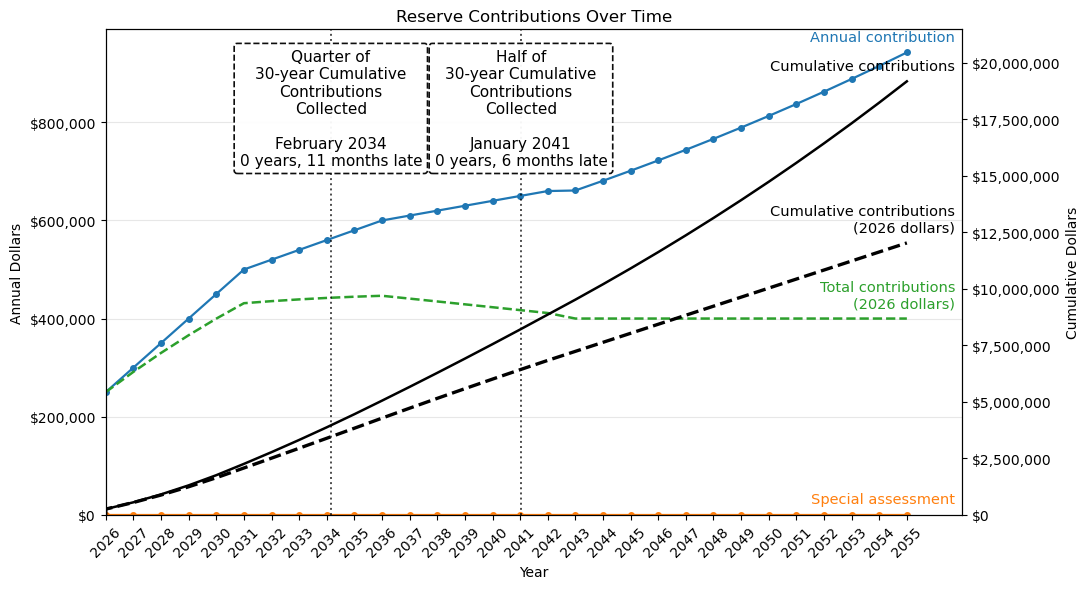

In [5]:

contribution_plot = assessment_contributions.copy()
contribution_plot = contribution_plot.sort_values("year").reset_index(drop=True)

base_year = analysis_year
first_year = int(contribution_plot["year"].min())
last_year = int(contribution_plot["year"].max())

contribution_plot["total_contributions"] = (
    contribution_plot["contribution"] + contribution_plot["special_assessment"]
)

contribution_plot["total_contributions_real"] = (
    contribution_plot["total_contributions"]
    / ((1 + inflation) ** (contribution_plot["year"] - base_year))
)

cumulative_plot = contribution_plot[["year", "total_contributions_real"]].copy()
cumulative_plot["cumulative_contributions_real"] = (
    cumulative_plot["total_contributions_real"].cumsum()
)

cumulative_plot_nominal = contribution_plot[["year", "total_contributions"]].copy()
cumulative_plot_nominal["cumulative_contributions"] = (
    cumulative_plot_nominal["total_contributions"].cumsum()
)

cumulative_plot = pd.concat(
    [
        pd.DataFrame(
            {
                "year": [base_year],
                "total_contributions_real": [0.0],
                "cumulative_contributions_real": [0.0],
            }
        ),
        cumulative_plot,
    ],
    ignore_index=True,
)

cumulative_plot_nominal = pd.concat(
    [
        pd.DataFrame(
            {
                "year": [base_year],
                "total_contributions": [0.0],
                "cumulative_contributions": [0.0],
            }
        ),
        cumulative_plot_nominal,
    ],
    ignore_index=True,
)

timeline_start = base_year
timeline_end = last_year

quarter_info = find_milestone_info(
    contribution_plot,
    "total_contributions_real",
    0.25,
    timeline_start,
    timeline_end,
)

half_info = find_milestone_info(
    contribution_plot,
    "total_contributions_real",
    0.50,
    timeline_start,
    timeline_end,
)

fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()

annual_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]
special_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][1]
real_total_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][2]
cumulative_color = "black"

ax.plot(
    contribution_plot["year"],
    contribution_plot["contribution"],
    marker="o",
    markersize=4,
    linewidth=1.6,
    linestyle="-",
    color=annual_color,
)

ax.plot(
    contribution_plot["year"],
    contribution_plot["special_assessment"],
    marker="o",
    markersize=4,
    linewidth=1.6,
    linestyle="-",
    color=special_color,
)

ax.plot(
    contribution_plot["year"],
    contribution_plot["total_contributions_real"],
    linewidth=1.8,
    linestyle="--",
    color=real_total_color,
)

ax2.plot(
    cumulative_plot_nominal["year"],
    cumulative_plot_nominal["cumulative_contributions"],
    color=cumulative_color,
    linewidth=1.8,
    linestyle="-",
)

ax2.plot(
    cumulative_plot["year"],
    cumulative_plot["cumulative_contributions_real"],
    color=cumulative_color,
    linewidth=2.4,
    linestyle="--",
)

ax.set_ylim(bottom=0)

cum_max = max(
    cumulative_plot_nominal["cumulative_contributions"].max(),
    cumulative_plot["cumulative_contributions_real"].max(),
)
ax2.set_ylim(0, cum_max * 1.12)

milestones = [
    {
        "info": quarter_info,
        "headline": "Quarter of\n30-year Cumulative\nContributions\nCollected",
        "text_y": 0.96,
    },
    {
        "info": half_info,
        "headline": "Half of\n30-year Cumulative\nContributions\nCollected",
        "text_y": 0.96,
    },
]

bbox_style = dict(
    boxstyle="round,pad=0.35,rounding_size=0.2",
    facecolor="white",
    edgecolor="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.95,
)

for m in milestones:
    info = m["info"]
    if info["x"] is None:
        continue

    ax2.axvline(
        x=info["x"],
        color="black",
        linewidth=1.4,
        linestyle=":",
        alpha=0.7,
    )

    y_top = ax2.get_ylim()[1]
    line_label_y = y_top * m["text_y"]

    label_text = (
        f'{m["headline"]}\n\n'
        f'{info["month_year"]}\n'
        f'{info["timing_text"]}'
    )

    ax2.annotate(
        label_text,
        xy=(info["x"], line_label_y),
        xytext=(0, 0),
        textcoords="offset points",
        ha="center",
        va="top",
        multialignment="center",
        fontsize=11,
        color="black",
        bbox=bbox_style,
    )

ax.set_title("Reserve Contributions Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Dollars")
ax2.set_ylabel("Cumulative Dollars")

all_years = sorted(
    set(cumulative_plot_nominal["year"]).union(set(cumulative_plot["year"]))
)
ax.set_xticks(all_years)
ax.tick_params(axis="x", rotation=45)

x_right_limit = contribution_plot["year"].max() + 2
ax.set_xlim(base_year, x_right_limit)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

ax.grid(True, axis="y", alpha=0.3)

fig.canvas.draw()

x_left, x_right = ax.get_xlim()
x_label = x_right - 0.25
label_fs = 10.5

ax.annotate(
    "Annual contribution",
    xy=(x_label, contribution_plot["contribution"].iloc[-1]),
    xytext=(0, 6),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=label_fs,
    color=annual_color,
)

ax.annotate(
    "Special assessment",
    xy=(x_label, contribution_plot["special_assessment"].iloc[-1]),
    xytext=(0, 6),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=label_fs,
    color=special_color,
)

ax.annotate(
    f"Total contributions\n({analysis_year} dollars)",
    xy=(x_label, contribution_plot["total_contributions_real"].iloc[-1]),
    xytext=(0, 6),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=label_fs,
    color=real_total_color,
)

ax2.annotate(
    "Cumulative contributions",
    xy=(x_label, cumulative_plot_nominal["cumulative_contributions"].iloc[-1]),
    xytext=(0, 6),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=label_fs,
    color=cumulative_color,
)

ax2.annotate(
    f"Cumulative contributions\n({analysis_year} dollars)",
    xy=(x_label, cumulative_plot["cumulative_contributions_real"].iloc[-1]),
    xytext=(0, 6),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=label_fs,
    color=cumulative_color,
)

fig.tight_layout()
plt.show()


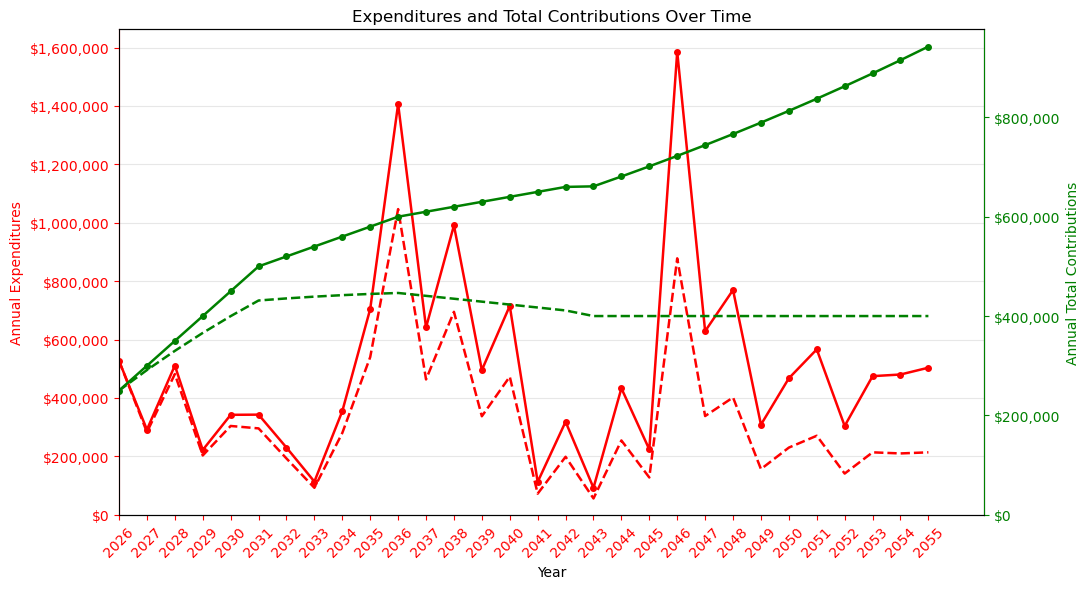

In [6]:
assessment_contributions = pd.read_csv(ASSESSMENT_FILE)
assessment_contributions.columns = assessment_contributions.columns.str.strip()

expenditures_by_year_detail = pd.read_csv(WORKING_CSV / "expenditures_by_year_detail.csv")
expenditures_by_year_detail.columns = expenditures_by_year_detail.columns.str.strip()

assumptions = pd.read_csv(ASSUMPTIONS_FILE)
assumptions.columns = assumptions.columns.str.strip()
assumptions["Parameter"] = assumptions["Parameter"].astype(str).str.strip()

assumptions_map = dict(zip(assumptions["Parameter"], assumptions["Value"]))

analysis_date = pd.to_datetime(assumptions_map["Analysis Date"])
analysis_year = int(analysis_date.year)

inflation_key = next(
    (k for k in assumptions_map.keys() if "inflation" in k.lower()),
    None,
)
if inflation_key is None:
    raise KeyError(
        f"Could not find an inflation parameter in assumptions.csv. "
        f"Available parameters: {list(assumptions_map.keys())}"
    )

inflation = float(assumptions_map[inflation_key])

plot_df = assessment_contributions.copy()

if "year" not in plot_df.columns:
    plot_df["year"] = range(analysis_year, analysis_year + len(plot_df))

plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce")
plot_df = plot_df.dropna(subset=["year"]).copy()
plot_df["year"] = plot_df["year"].astype(int)
plot_df = plot_df.sort_values("year").reset_index(drop=True)

plot_df["annual_contribution"] = pd.to_numeric(
    plot_df["annual_contribution"], errors="coerce"
).fillna(0)

if "special_assessment" not in plot_df.columns:
    plot_df["special_assessment"] = 0.0

plot_df["special_assessment"] = pd.to_numeric(
    plot_df["special_assessment"], errors="coerce"
).fillna(0)

plot_df["total_contributions"] = (
    plot_df["annual_contribution"] + plot_df["special_assessment"]
)

exp_year_col = None
for c in ["year", "expenditure_year", "replacement_year"]:
    if c in expenditures_by_year_detail.columns:
        exp_year_col = c
        break

if exp_year_col is None:
    expenditures_by_year_detail = expenditures_by_year_detail.copy()
    expenditures_by_year_detail["year"] = range(
        analysis_year, analysis_year + len(expenditures_by_year_detail)
    )
    exp_year_col = "year"

exp_amount_col = None
for c in ["amount", "expenditure", "cost", "future_cost", "project_cost"]:
    if c in expenditures_by_year_detail.columns:
        exp_amount_col = c
        break

if exp_amount_col is None:
    raise KeyError(
        f"Could not find expenditure amount column. "
        f"Columns are: {list(expenditures_by_year_detail.columns)}"
    )

expenditures_by_year_detail[exp_year_col] = pd.to_numeric(
    expenditures_by_year_detail[exp_year_col], errors="coerce"
)
expenditures_by_year_detail[exp_amount_col] = pd.to_numeric(
    expenditures_by_year_detail[exp_amount_col], errors="coerce"
).fillna(0)

expenditures_by_year_detail = expenditures_by_year_detail.dropna(
    subset=[exp_year_col]
).copy()
expenditures_by_year_detail[exp_year_col] = expenditures_by_year_detail[
    exp_year_col
].astype(int)

exp_by_year = (
    expenditures_by_year_detail.groupby(exp_year_col, as_index=False)[exp_amount_col]
    .sum()
    .rename(columns={exp_year_col: "year", exp_amount_col: "expenditures"})
)

plot_df = plot_df.merge(exp_by_year, on="year", how="left")
plot_df["expenditures"] = plot_df["expenditures"].fillna(0)

inflation_factor = (1 + inflation) ** (plot_df["year"] - analysis_year)
plot_df["expenditures_real"] = plot_df["expenditures"] / inflation_factor
plot_df["total_contributions_real"] = plot_df["total_contributions"] / inflation_factor

fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()

exp_color = "red"
contrib_color = "green"

ax.plot(
    plot_df["year"],
    plot_df["expenditures"],
    marker="o",
    markersize=4,
    linewidth=1.8,
    linestyle="-",
    color=exp_color,
)

ax.plot(
    plot_df["year"],
    plot_df["expenditures_real"],
    linewidth=1.8,
    linestyle="--",
    color=exp_color,
)

ax2.plot(
    plot_df["year"],
    plot_df["total_contributions"],
    marker="o",
    markersize=4,
    linewidth=1.8,
    linestyle="-",
    color=contrib_color,
)

ax2.plot(
    plot_df["year"],
    plot_df["total_contributions_real"],
    linewidth=1.8,
    linestyle="--",
    color=contrib_color,
)

ax.set_title("Expenditures and Total Contributions Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Expenditures", color=exp_color)
ax2.set_ylabel("Annual Total Contributions", color=contrib_color)

ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

all_years = sorted(plot_df["year"].unique())
ax.set_xticks(all_years)
ax.tick_params(axis="x", rotation=45, colors=exp_color)
ax.tick_params(axis="y", colors=exp_color)
ax2.tick_params(axis="y", colors=contrib_color)

ax.spines["left"].set_color(exp_color)
ax2.spines["right"].set_color(contrib_color)
ax.yaxis.label.set_color(exp_color)
ax2.yaxis.label.set_color(contrib_color)

x_right_limit = plot_df["year"].max() + 2
ax.set_xlim(plot_df["year"].min(), x_right_limit)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

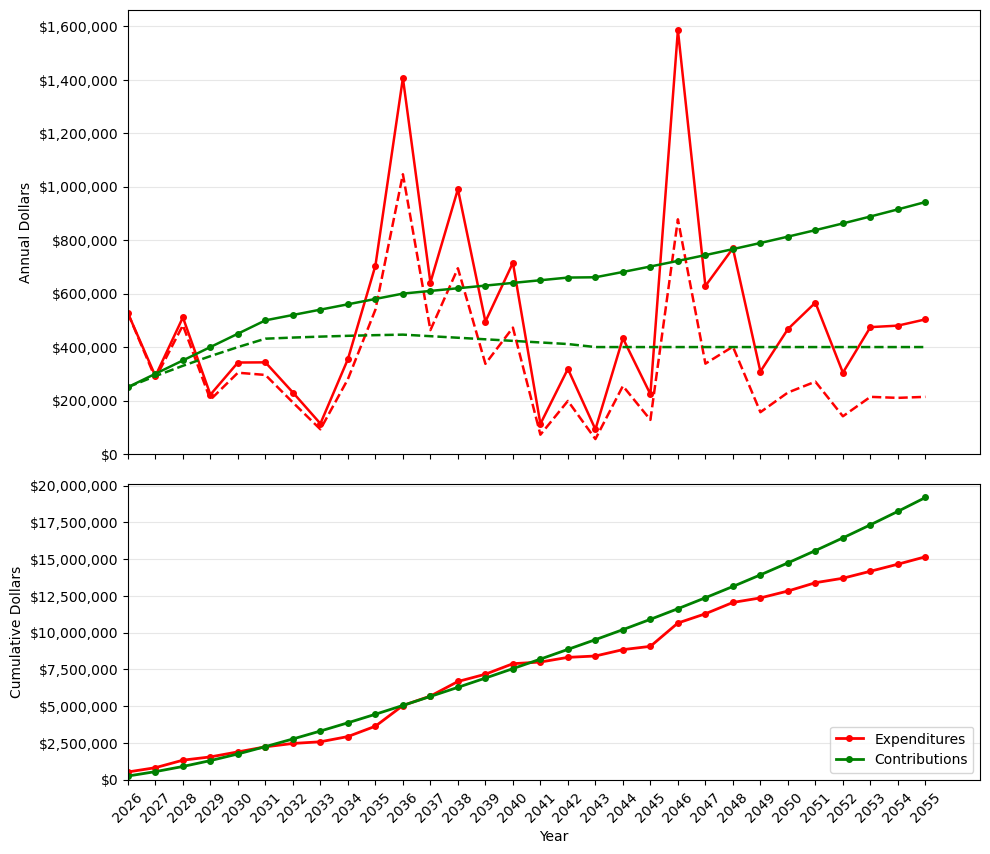

In [7]:
assessment_contributions = pd.read_csv(ASSESSMENT_FILE)
assessment_contributions.columns = assessment_contributions.columns.str.strip()

expenditures_by_year_detail = pd.read_csv(WORKING_CSV / "expenditures_by_year_detail.csv")
expenditures_by_year_detail.columns = expenditures_by_year_detail.columns.str.strip()

assumptions = pd.read_csv(ASSUMPTIONS_FILE)
assumptions.columns = assumptions.columns.str.strip()
assumptions["Parameter"] = assumptions["Parameter"].astype(str).str.strip()

assumptions_map = dict(zip(assumptions["Parameter"], assumptions["Value"]))

analysis_date = pd.to_datetime(assumptions_map["Analysis Date"])
analysis_year = int(analysis_date.year)

inflation_key = next(
    (k for k in assumptions_map.keys() if "inflation" in k.lower()),
    None,
)
if inflation_key is None:
    raise KeyError(
        f"Could not find an inflation parameter in assumptions.csv. "
        f"Available parameters: {list(assumptions_map.keys())}"
    )

inflation = float(assumptions_map[inflation_key])

plot_df = assessment_contributions.copy()

if "year" not in plot_df.columns:
    plot_df["year"] = range(analysis_year, analysis_year + len(plot_df))

plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce")
plot_df = plot_df.dropna(subset=["year"]).copy()
plot_df["year"] = plot_df["year"].astype(int)
plot_df = plot_df.sort_values("year").reset_index(drop=True)

plot_df["annual_contribution"] = pd.to_numeric(
    plot_df["annual_contribution"], errors="coerce"
).fillna(0)

if "special_assessment" not in plot_df.columns:
    plot_df["special_assessment"] = 0.0

plot_df["special_assessment"] = pd.to_numeric(
    plot_df["special_assessment"], errors="coerce"
).fillna(0)

plot_df["total_contributions"] = (
    plot_df["annual_contribution"] + plot_df["special_assessment"]
)

exp_year_col = None
for c in ["year", "expenditure_year", "replacement_year"]:
    if c in expenditures_by_year_detail.columns:
        exp_year_col = c
        break

if exp_year_col is None:
    expenditures_by_year_detail = expenditures_by_year_detail.copy()
    expenditures_by_year_detail["year"] = range(
        analysis_year, analysis_year + len(expenditures_by_year_detail)
    )
    exp_year_col = "year"

exp_amount_col = None
for c in ["amount", "expenditure", "cost", "future_cost", "project_cost"]:
    if c in expenditures_by_year_detail.columns:
        exp_amount_col = c
        break

if exp_amount_col is None:
    raise KeyError(
        f"Could not find expenditure amount column. "
        f"Columns are: {list(expenditures_by_year_detail.columns)}"
    )

expenditures_by_year_detail[exp_year_col] = pd.to_numeric(
    expenditures_by_year_detail[exp_year_col], errors="coerce"
)
expenditures_by_year_detail[exp_amount_col] = pd.to_numeric(
    expenditures_by_year_detail[exp_amount_col], errors="coerce"
).fillna(0)

expenditures_by_year_detail = expenditures_by_year_detail.dropna(
    subset=[exp_year_col]
).copy()
expenditures_by_year_detail[exp_year_col] = expenditures_by_year_detail[
    exp_year_col
].astype(int)

exp_by_year = (
    expenditures_by_year_detail.groupby(exp_year_col, as_index=False)[exp_amount_col]
    .sum()
    .rename(columns={exp_year_col: "year", exp_amount_col: "expenditures"})
)

plot_df = plot_df.merge(exp_by_year, on="year", how="left")
plot_df["expenditures"] = plot_df["expenditures"].fillna(0)

inflation_factor = (1 + inflation) ** (plot_df["year"] - analysis_year)
plot_df["expenditures_real"] = plot_df["expenditures"] / inflation_factor
plot_df["total_contributions_real"] = plot_df["total_contributions"] / inflation_factor

plot_df["cumulative_expenditures"] = plot_df["expenditures"].cumsum()
plot_df["cumulative_contributions"] = plot_df["total_contributions"].cumsum()

exp_color = "red"
contrib_color = "green"

fig, (ax, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(11, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08},
)

# Top plot: one shared annual-dollar axis
ax.plot(
    plot_df["year"],
    plot_df["expenditures"],
    marker="o",
    markersize=4,
    linewidth=1.8,
    linestyle="-",
    color=exp_color,
)

ax.plot(
    plot_df["year"],
    plot_df["expenditures_real"],
    linewidth=1.8,
    linestyle="--",
    color=exp_color,
)

ax.plot(
    plot_df["year"],
    plot_df["total_contributions"],
    marker="o",
    markersize=4,
    linewidth=1.8,
    linestyle="-",
    color=contrib_color,
)

ax.plot(
    plot_df["year"],
    plot_df["total_contributions_real"],
    linewidth=1.8,
    linestyle="--",
    color=contrib_color,
)

ax.set_ylabel("Annual Dollars")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.grid(True, axis="y", alpha=0.3)

# Bottom plot
line_exp, = ax_bottom.plot(
    plot_df["year"],
    plot_df["cumulative_expenditures"],
    marker="o",
    markersize=4,
    linewidth=2.0,
    linestyle="-",
    color=exp_color,
    label="Expenditures",
)

line_contrib, = ax_bottom.plot(
    plot_df["year"],
    plot_df["cumulative_contributions"],
    marker="o",
    markersize=4,
    linewidth=2.0,
    linestyle="-",
    color=contrib_color,
    label="Contributions",
)

ax_bottom.set_xlabel("Year")
ax_bottom.set_ylabel("Cumulative Dollars")
ax_bottom.set_ylim(bottom=0)
ax_bottom.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax_bottom.grid(True, axis="y", alpha=0.3)

all_years = sorted(plot_df["year"].unique())
ax_bottom.set_xticks(all_years)
ax_bottom.tick_params(axis="x", rotation=45)

x_right_limit = plot_df["year"].max() + 2
ax_bottom.set_xlim(plot_df["year"].min(), x_right_limit)

ax.set_title("")
ax_bottom.set_title("")

ax_bottom.legend(
    handles=[line_exp, line_contrib],
    loc="lower right",
)

plt.show()

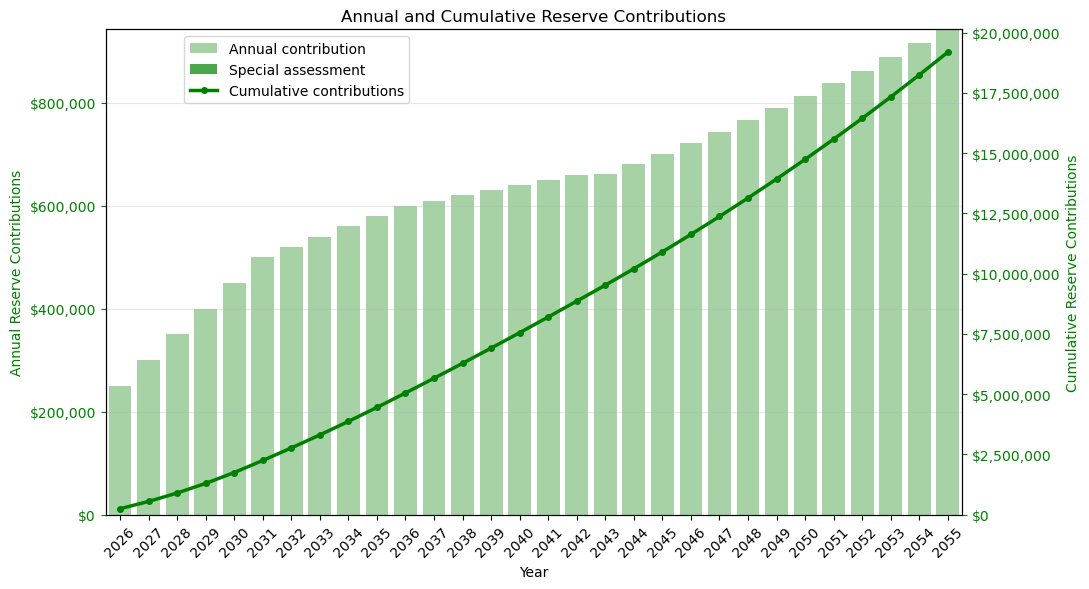

In [8]:
assessment_contributions = pd.read_csv(ASSESSMENT_FILE)
assessment_contributions.columns = assessment_contributions.columns.str.strip()

debug_df = assessment_contributions.copy()

if "year" not in debug_df.columns:
    assumptions = pd.read_csv(ASSUMPTIONS_FILE)
    assumptions.columns = assumptions.columns.str.strip()
    assumptions["Parameter"] = assumptions["Parameter"].astype(str).str.strip()
    assumptions_map = dict(zip(assumptions["Parameter"], assumptions["Value"]))
    analysis_date = pd.to_datetime(assumptions_map["Analysis Date"])
    analysis_year = int(analysis_date.year)
    debug_df["year"] = range(analysis_year, analysis_year + len(debug_df))

debug_df["year"] = pd.to_numeric(debug_df["year"], errors="coerce")
debug_df = debug_df.dropna(subset=["year"]).copy()
debug_df["year"] = debug_df["year"].astype(int)
debug_df = debug_df.sort_values("year").reset_index(drop=True)

debug_df["annual_contribution"] = pd.to_numeric(
    debug_df["annual_contribution"], errors="coerce"
).fillna(0)

if "special_assessment" not in debug_df.columns:
    debug_df["special_assessment"] = 0.0

debug_df["special_assessment"] = pd.to_numeric(
    debug_df["special_assessment"], errors="coerce"
).fillna(0)

debug_df["total_contributions"] = (
    debug_df["annual_contribution"] + debug_df["special_assessment"]
)

debug_df["cumulative_contributions"] = debug_df["total_contributions"].cumsum()

fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()

green = "green"

ax.bar(
    debug_df["year"],
    debug_df["annual_contribution"],
    width=0.8,
    color=green,
    alpha=0.35,
    label="Annual contribution",
)

ax.bar(
    debug_df["year"],
    debug_df["special_assessment"],
    width=0.8,
    bottom=debug_df["annual_contribution"],
    color=green,
    alpha=0.7,
    label="Special assessment",
)

ax2.plot(
    debug_df["year"],
    debug_df["cumulative_contributions"],
    color=green,
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Cumulative contributions",
)

ax.set_title("Annual and Cumulative Reserve Contributions")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Contributions", color=green)
ax2.set_ylabel("Cumulative Reserve Contributions", color=green)

ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", colors=green)
ax2.tick_params(axis="y", colors=green)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

ax.set_xticks(debug_df["year"])
ax.set_xlim(debug_df["year"].min() - 0.5, debug_df["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(2028, ax.get_ylim()[1]),
    bbox_transform=ax.transData,
)
fig.tight_layout()
plt.show()

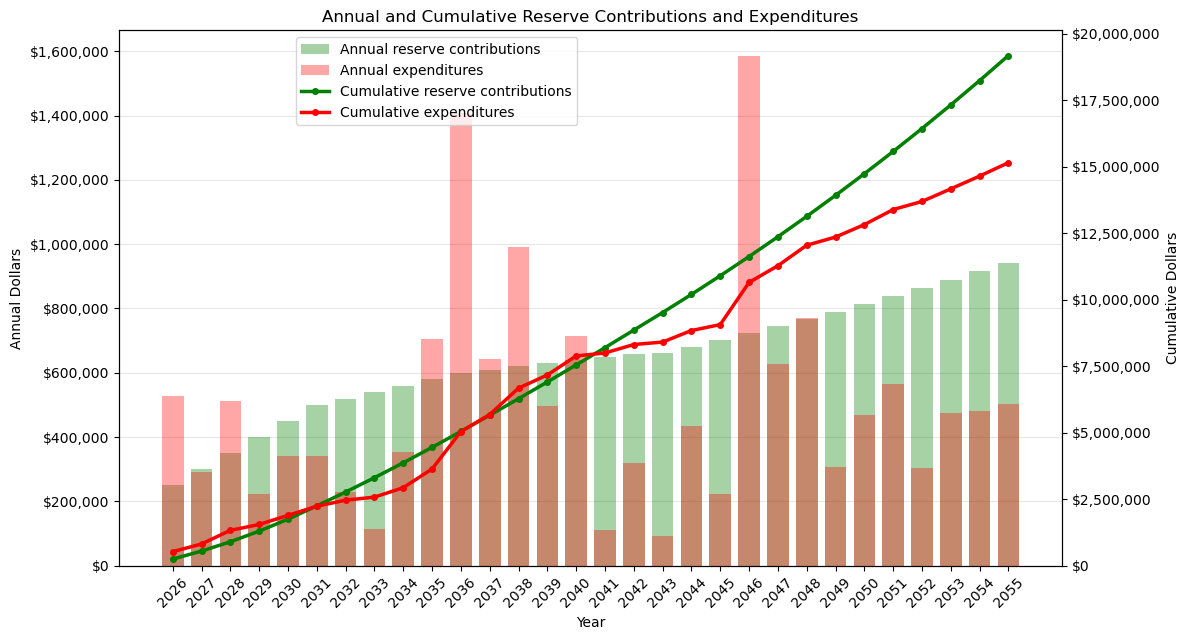

In [9]:
assessment_contributions = pd.read_csv(ASSESSMENT_FILE)
assessment_contributions.columns = assessment_contributions.columns.str.strip()

expenditures_by_year_detail = pd.read_csv(WORKING_CSV / "expenditures_by_year_detail.csv")
expenditures_by_year_detail.columns = expenditures_by_year_detail.columns.str.strip()

debug_df = assessment_contributions.copy()

if "year" not in debug_df.columns:
    assumptions = pd.read_csv(ASSUMPTIONS_FILE)
    assumptions.columns = assumptions.columns.str.strip()
    assumptions["Parameter"] = assumptions["Parameter"].astype(str).str.strip()
    assumptions_map = dict(zip(assumptions["Parameter"], assumptions["Value"]))
    analysis_date = pd.to_datetime(assumptions_map["Analysis Date"])
    analysis_year = int(analysis_date.year)
    debug_df["year"] = range(analysis_year, analysis_year + len(debug_df))

debug_df["year"] = pd.to_numeric(debug_df["year"], errors="coerce")
debug_df = debug_df.dropna(subset=["year"]).copy()
debug_df["year"] = debug_df["year"].astype(int)
debug_df = debug_df.sort_values("year").reset_index(drop=True)

debug_df["annual_contribution"] = pd.to_numeric(
    debug_df["annual_contribution"], errors="coerce"
).fillna(0)

if "special_assessment" not in debug_df.columns:
    debug_df["special_assessment"] = 0.0

debug_df["special_assessment"] = pd.to_numeric(
    debug_df["special_assessment"], errors="coerce"
).fillna(0)

debug_df["total_contributions"] = (
    debug_df["annual_contribution"] + debug_df["special_assessment"]
)

exp_year_col = None
for c in ["year", "expenditure_year", "replacement_year"]:
    if c in expenditures_by_year_detail.columns:
        exp_year_col = c
        break

if exp_year_col is None:
    raise KeyError(
        f"Could not find expenditure year column. Columns are: {list(expenditures_by_year_detail.columns)}"
    )

exp_amount_col = None
for c in ["amount", "expenditure", "cost", "future_cost", "project_cost"]:
    if c in expenditures_by_year_detail.columns:
        exp_amount_col = c
        break

if exp_amount_col is None:
    raise KeyError(
        f"Could not find expenditure amount column. Columns are: {list(expenditures_by_year_detail.columns)}"
    )

expenditures_by_year_detail[exp_year_col] = pd.to_numeric(
    expenditures_by_year_detail[exp_year_col], errors="coerce"
)
expenditures_by_year_detail[exp_amount_col] = pd.to_numeric(
    expenditures_by_year_detail[exp_amount_col], errors="coerce"
).fillna(0)

expenditures_by_year_detail = expenditures_by_year_detail.dropna(
    subset=[exp_year_col]
).copy()
expenditures_by_year_detail[exp_year_col] = expenditures_by_year_detail[
    exp_year_col
].astype(int)

exp_by_year = (
    expenditures_by_year_detail.groupby(exp_year_col, as_index=False)[exp_amount_col]
    .sum()
    .rename(columns={exp_year_col: "year", exp_amount_col: "expenditures"})
)

debug_df = debug_df.merge(exp_by_year, on="year", how="left")
debug_df["expenditures"] = debug_df["expenditures"].fillna(0)

debug_df["cumulative_contributions"] = debug_df["total_contributions"].cumsum()
debug_df["cumulative_expenditures"] = debug_df["expenditures"].cumsum()

green = "green"
red = "red"

fig, ax = plt.subplots(figsize=(12, 6.5))
ax2 = ax.twinx()

bar_width = 0.75

ax.bar(
    debug_df["year"],
    debug_df["total_contributions"],
    width=bar_width,
    color=green,
    alpha=0.35,
    label="Annual reserve contributions",
    zorder=2,
)

ax.bar(
    debug_df["year"],
    debug_df["expenditures"],
    width=bar_width,
    color=red,
    alpha=0.35,
    label="Annual expenditures",
    zorder=3,
)

ax2.plot(
    debug_df["year"],
    debug_df["cumulative_contributions"],
    color=green,
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Cumulative reserve contributions",
    zorder=4,
)

ax2.plot(
    debug_df["year"],
    debug_df["cumulative_expenditures"],
    color=red,
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Cumulative expenditures",
    zorder=5,
)

ax.set_title("Annual and Cumulative Reserve Contributions and Expenditures")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Dollars")
ax2.set_ylabel("Cumulative Dollars")

ax.set_xticks(debug_df["year"])
ax.tick_params(axis="x", rotation=45)

ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(0.18, 1.0),
)
fig.tight_layout()
plt.show()

### Contributions, expenditures, balance, and funded amount

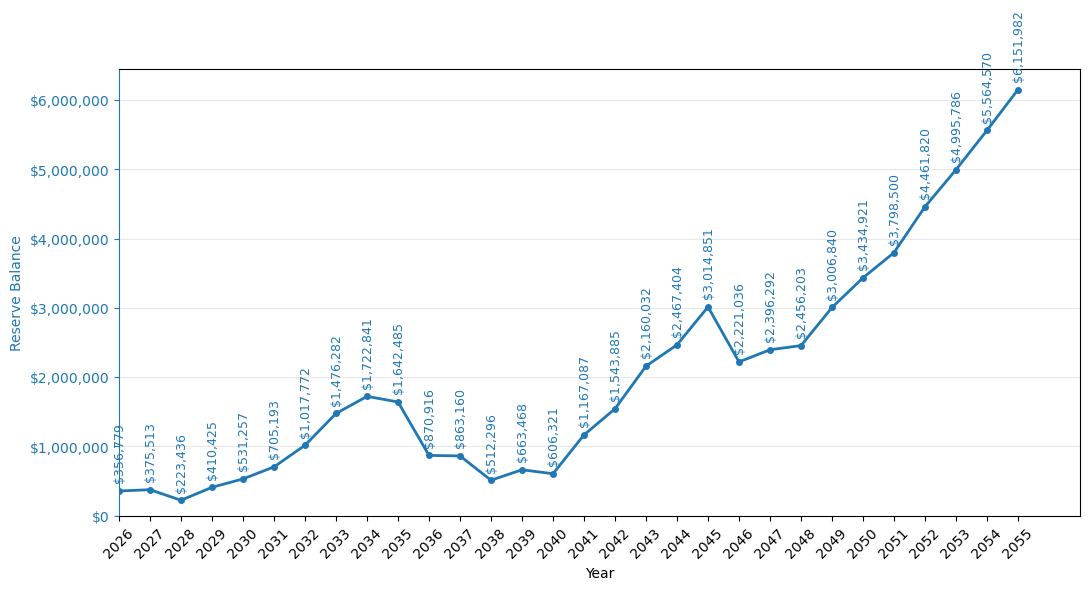

In [10]:
proj = reserve_projection.copy()
proj.columns = proj.columns.str.strip()

if "year" not in proj.columns:
    raise KeyError(
        f"Could not find 'year' in reserve_projection. Columns are: {list(proj.columns)}"
    )

balance_col = None
for c in ["end_balance", "ending_balance", "reserve_balance"]:
    if c in proj.columns:
        balance_col = c
        break

if balance_col is None:
    raise KeyError(
        f"Could not find a balance column in reserve_projection. Columns are: {list(proj.columns)}"
    )

proj["year"] = pd.to_numeric(proj["year"], errors="coerce")
proj[balance_col] = pd.to_numeric(proj[balance_col], errors="coerce")

proj = proj.dropna(subset=["year", balance_col]).copy()
proj["year"] = proj["year"].astype(int)
proj = proj.sort_values("year").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))

balance_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]

ax.plot(
    proj["year"],
    proj[balance_col],
    marker="o",
    markersize=4,
    linewidth=2.0,
    linestyle="-",
    color=balance_color,
)

ax.set_xlabel("Year")
ax.set_ylabel("Reserve Balance", color=balance_color)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", colors=balance_color)
ax.spines["left"].set_color(balance_color)
ax.yaxis.label.set_color(balance_color)

ax.set_xticks(proj["year"])
ax.set_xlim(proj["year"].min(), proj["year"].max() + 2)
ax.set_ylim(bottom=0)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.grid(True, axis="y", alpha=0.3)

y_offset = proj[balance_col].max() * 0.015

for _, row in proj.iterrows():
    ax.annotate(
        f'${row[balance_col]:,.0f}',
        xy=(row["year"], row[balance_col]),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9,
        color=balance_color,
    )

plt.tight_layout()
plt.show()